# Datathon Passos Mágicos - Fase 5
## Parte 1 - Análise exploratória dos dados

O proposito desse notebook e explorar os dados: quantos registros existem, quais colunas, o que está faltando, se tem duplicata e
como os indicadores se distribuem.

A base vem da pesquisa PEDE da Passos Mágicos, com uma aba por ano (2022, 2023 e 2024).
O nome das colunas muda de um ano para o outro, então a consolidação das três abas está em
`src/data_cleaning.py`.

In [1]:
import os
import sys

# sobe a partir da pasta atual ate achar a raiz do projeto, pra funcionar tanto
# abrindo o notebook de dentro de notebooks/ quanto da raiz do repositorio
RAIZ = os.getcwd()
while not os.path.isdir(os.path.join(RAIZ, "src")) and os.path.dirname(RAIZ) != RAIZ:
    RAIZ = os.path.dirname(RAIZ)
sys.path.insert(0, os.path.join(RAIZ, "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_cleaning import load_consolidated

VERMELHO = "#ED3237"
LARANJA  = "#F58334"
AMARELO  = "#FBBA00"
VERDE    = "#37CD8F"
AZUL     = "#5CA7E8"
NAVY     = "#1B2A4A"
CINZA    = "#9AA0A6"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})
pd.set_option("display.max_columns", 40)

### 1. Carregando e consolidando as três abas

In [2]:
df = load_consolidated()

print("Formato da base consolidada:", df.shape)
print("Alunos distintos:", df["ra"].nunique())
print()
print("Registros por ano:")
print(df["ano_pesquisa"].value_counts().sort_index().to_string())

Formato da base consolidada: (3030, 35)
Alunos distintos: 1661

Registros por ano:
ano_pesquisa
2022     860
2023    1014
2024    1156


In [3]:
df.head()

     ra  ano_pesquisa fase turma     genero  idade  ano_ingresso  \
0  RA-1          2022    7     A   Feminino   19.0          2016   
1  RA-2          2022    7     A   Feminino   17.0          2017   
2  RA-3          2022    7     A   Feminino   17.0          2016   
3  RA-4          2022    7     A  Masculino   17.0          2017   
4  RA-5          2022    7     A   Feminino   17.0          2016   

  instituicao_ensino     pedra   inde  iaa  ieg  ips  ipp  ida    ipv   ian  \
0     Escola Pública   Quartzo  5.783  8.3  4.1  5.6  NaN  4.0  7.278   5.0   
1       Rede Decisão  Ametista  7.055  8.8  5.2  6.3  NaN  6.8  6.778  10.0   
2       Rede Decisão     Ágata  6.591  0.0  7.9  5.6  NaN  5.6  7.556  10.0   
3       Rede Decisão   Quartzo  5.951  8.8  4.5  5.6  NaN  5.0  5.278  10.0   
4       Rede Decisão  Ametista  7.427  7.9  8.6  5.6  NaN  5.2  7.389  10.0   

   nota_mat  nota_por  nota_ing indicado_bolsa atingiu_pv  \
0       2.7       3.5       6.0           True      Fal

Cada linha é um aluno num ano. Como o mesmo aluno aparece em mais de um ano, o total de
registros é maior que o número de alunos distintos.

### 2. Tipos de dados e valores faltantes

In [4]:
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(1),
    "valores únicos": df.nunique(),
})
resumo.sort_values("% nulos", ascending=False)

                       tipo  nulos  % nulos  valores únicos
destaque_ida         object   2170     71.6               2
destaque_ieg         object   2170     71.6               2
ct                  float64   2170     71.6              18
indicado_bolsa       object   2170     71.6               2
cg                  float64   2170     71.6             860
atingiu_pv           object   2170     71.6               2
cf                  float64   2170     71.6             192
rec_psicologia       object   2170     71.6               5
destaque_ipv         object   2170     71.6               2
nota_ing            float64   1939     64.0              84
ipp                 float64   1038     34.3              86
idade               float64    399     13.2              20
pedra_ord           float64    185      6.1               4
inde                float64    185      6.1            2708
nota_mat            float64    184      6.1              83
nota_por            float64    185      

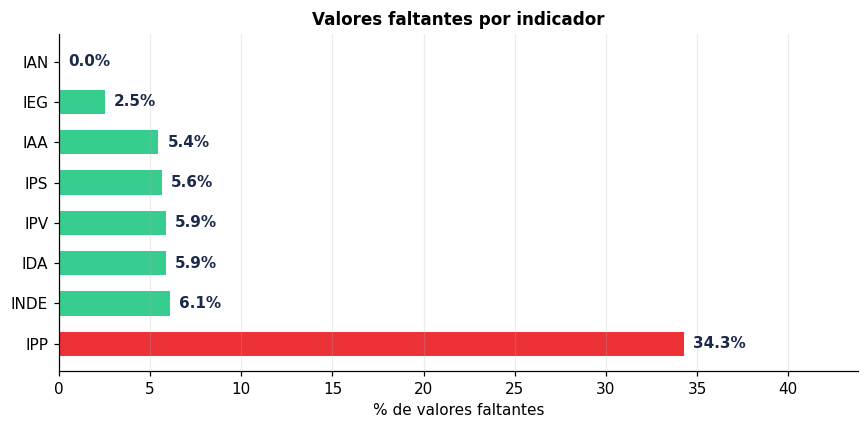

In [5]:
indicadores = ["ian", "ida", "ieg", "iaa", "ips", "ipp", "ipv", "inde"]
faltantes = (df[indicadores].isna().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
cores = [VERMELHO if v > 30 else (LARANJA if v > 10 else VERDE) for v in faltantes.values]
barras = ax.barh([i.upper() for i in faltantes.index], faltantes.values, color=cores, height=0.6)
for b, v in zip(barras, faltantes.values):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f"{v:.1f}%", va="center",
            fontweight="bold", fontsize=10, color=NAVY)
ax.set_xlabel("% de valores faltantes")
ax.set_xlim(0, max(faltantes.values) * 1.25 + 1)
ax.set_title("Valores faltantes por indicador", fontsize=11, fontweight="bold")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

In [6]:
# o IPP so passou a ser coletado a partir de 2023
print("% de nulos no IPP por ano:")
print((df.groupby("ano_pesquisa")["ipp"].apply(lambda s: s.isna().mean() * 100)).round(1).to_string())

% de nulos no IPP por ano:
ano_pesquisa
2022    100.0
2023      7.5
2024      8.8


O IPP é o indicador com mais buracos, e a razão fica clara ao abrir por ano: ele só passou
a ser coletado a partir de 2023. Não é erro de digitação, é mudança na própria pesquisa — então
faz sentido manter a coluna e tratar a ausência como ausência mesmo.

### 3. Duplicatas e consistência

In [7]:
dup_total = df.duplicated().sum()
dup_chave = df.duplicated(subset=["ra", "ano_pesquisa"]).sum()

print("Linhas totalmente duplicadas:", dup_total)
print("Duplicatas de aluno+ano (não deveria existir):", dup_chave)
print()

# quantos anos cada aluno aparece
anos_por_aluno = df.groupby("ra")["ano_pesquisa"].nunique().value_counts().sort_index()
print("Em quantos anos cada aluno aparece:")
for n, qtd in anos_por_aluno.items():
    print(f"  {n} ano(s): {qtd} alunos")

Linhas totalmente duplicadas: 0
Duplicatas de aluno+ano (não deveria existir): 0

Em quantos anos cada aluno aparece:
  1 ano(s): 760 alunos
  2 ano(s): 433 alunos
  3 ano(s): 468 alunos


Não há duplicatas de aluno+ano, que é a chave da base. Boa parte dos alunos aparece em mais
de um ano, o que é justamente o que torna possível a análise longitudinal do notebook 03 e o
modelo preditivo do notebook 02.

### 4. Como os indicadores se distribuem

In [8]:
df[indicadores].describe().round(2)

           ian      ida      ieg      iaa      ips      ipp      ipv     inde
count  3030.00  2852.00  2954.00  2865.00  2859.00  1992.00  2852.00  2845.00
mean      7.18     6.38     7.95     7.92     6.29     7.56     7.55     7.27
std       2.54     1.96     2.15     2.63     1.79     0.94     1.08     0.99
min       2.50     0.00     0.00     0.00     2.50     2.50     2.50     3.03
25%       5.00     5.10     7.30     7.90     5.02     7.08     6.98     6.68
50%       5.00     6.67     8.60     8.75     7.50     7.50     7.58     7.39
75%      10.00     7.83     9.40     9.50     7.51     8.12     8.26     7.99
max      10.00    10.00    10.00    10.00    10.00    10.00    10.01     9.53

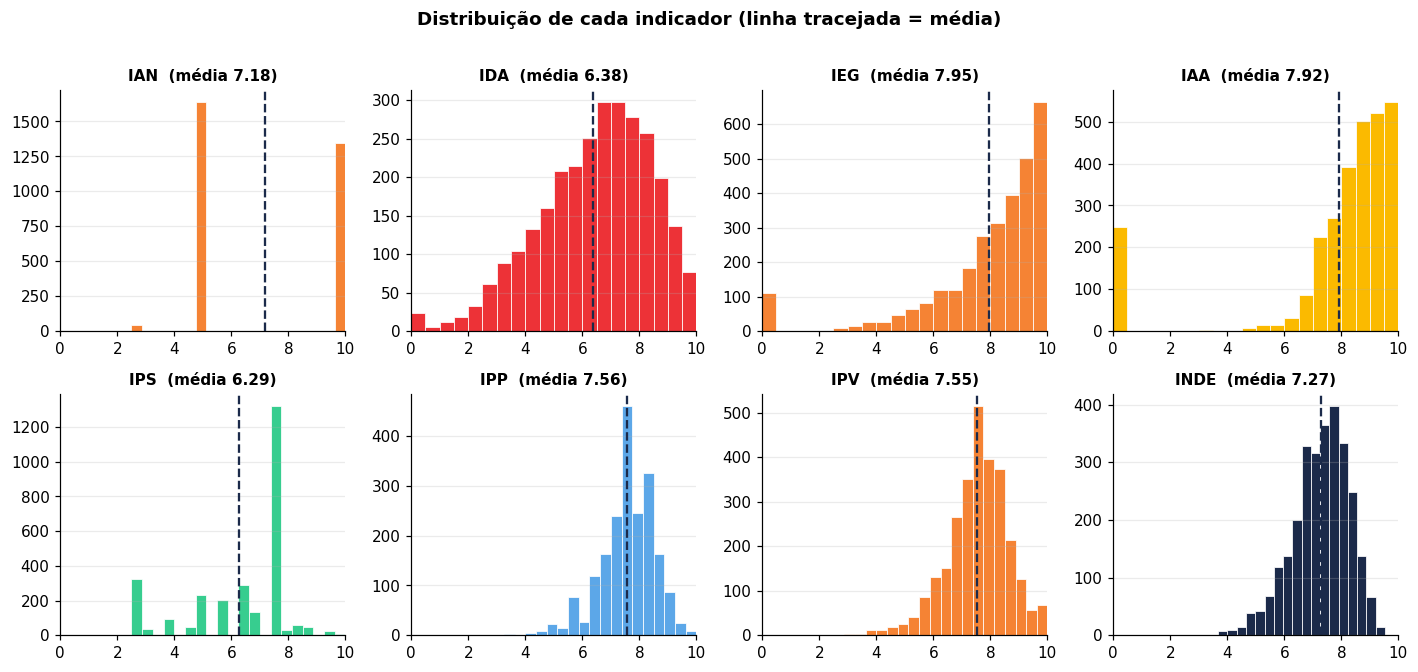

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6))
paleta = [LARANJA, VERMELHO, LARANJA, AMARELO, VERDE, AZUL, LARANJA, NAVY]

for ax, ind, cor in zip(axes.ravel(), indicadores, paleta):
    dados = df[ind].dropna()
    ax.hist(dados, bins=20, color=cor, edgecolor="white", linewidth=0.5)
    ax.axvline(dados.mean(), color=NAVY, linestyle="--", linewidth=1.5)
    ax.set_title(f"{ind.upper()}  (média {dados.mean():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlim(0, 10)
    ax.grid(axis="x")

fig.suptitle("Distribuição de cada indicador (linha tracejada = média)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Chamam atenção duas coisas: o IEG e o IAA são bem puxados para a direita (a maioria dos
alunos tira nota alta), enquanto o IDA é o mais espalhado e o único com massa relevante abaixo
de 5. O IAN tem um formato bem particular, com picos em valores específicos — o que faz sentido,
já que ele deriva de uma contagem de fases de defasagem e não de uma nota contínua.

### 5. Correlação entre os indicadores

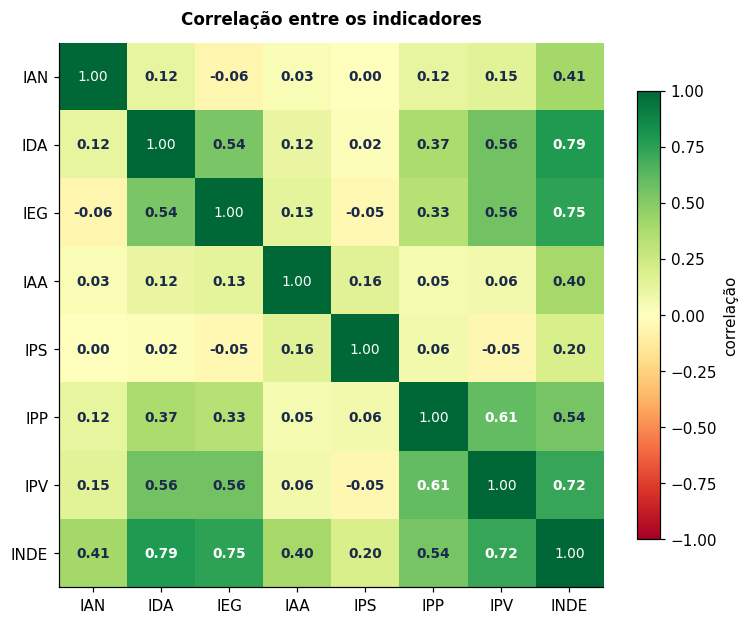

In [10]:
corr = df[indicadores].corr()

fig, ax = plt.subplots(figsize=(7, 5.8))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)

rotulos = [i.upper() for i in indicadores]
ax.set_xticks(range(len(rotulos)), rotulos)
ax.set_yticks(range(len(rotulos)), rotulos)

for i in range(len(rotulos)):
    for j in range(len(rotulos)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(v) > 0.6 else NAVY,
                fontweight="bold" if i != j else "normal")

ax.set_title("Correlação entre os indicadores", fontsize=11, fontweight="bold", pad=12)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlação")
plt.tight_layout()
plt.show()

In [11]:
# pares mais correlacionados, ignorando a diagonal
pares = corr.where(~np.eye(len(corr), dtype=bool)).stack().sort_values(ascending=False)
pares = pares[::2]  # cada par aparece duas vezes na matriz
print("Pares mais correlacionados:")
print(pares.head(6).round(2).to_string())
print()
print("Pares menos correlacionados:")
print(pares.tail(4).round(2).to_string())

Pares mais correlacionados:
ida   inde    0.79
inde  ieg     0.75
      ipv     0.72
ipp   ipv     0.61
ieg   ipv     0.56
ipv   ida     0.56

Pares menos correlacionados:
ips  ian    0.00
ieg  ips   -0.05
ips  ipv   -0.05
ieg  ian   -0.06


O INDE aparece bastante correlacionado com quase tudo, o que é esperado: ele é uma nota
composta pelos outros indicadores. Fora isso, o bloco IDA / IEG / IPV se move junto, enquanto o
IPS e o IAA ficam bem soltos do resto — dois indicadores que medem algo próprio.

### 6. Perfil dos alunos

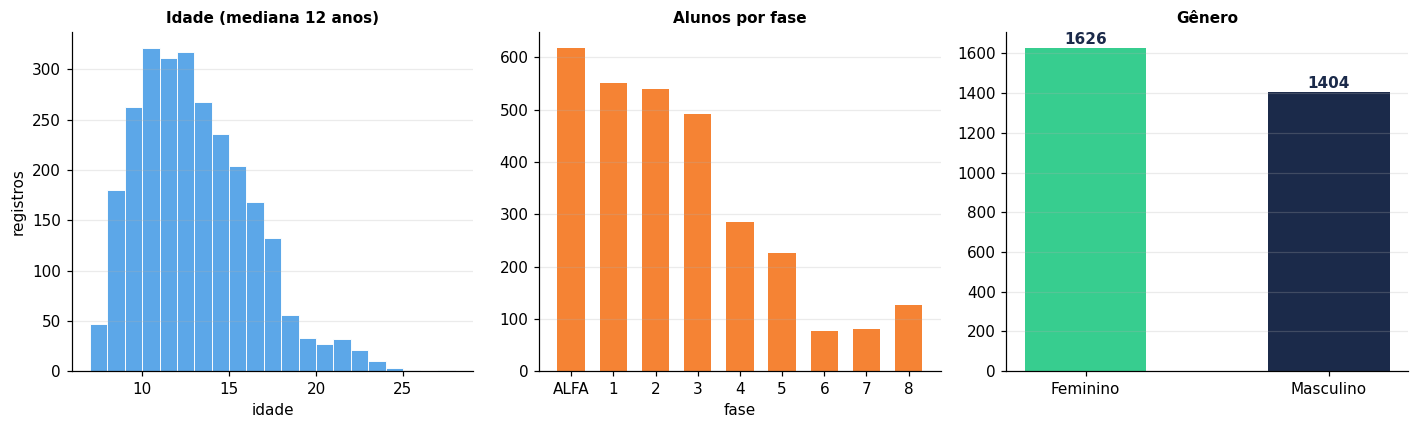

In [12]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))

idades = df["idade"].dropna()
ax1.hist(idades, bins=range(int(idades.min()), int(idades.max()) + 2),
         color=AZUL, edgecolor="white", linewidth=0.6)
ax1.set_xlabel("idade")
ax1.set_ylabel("registros")
ax1.set_title(f"Idade (mediana {idades.median():.0f} anos)", fontsize=10, fontweight="bold")
ax1.grid(axis="x")

fase_cont = df["fase_ord"].dropna().astype(int).value_counts().sort_index()
ax2.bar(fase_cont.index, fase_cont.values, color=LARANJA, width=0.65)
ax2.set_xticks(fase_cont.index)
ax2.set_xticklabels(["ALFA" if f == 0 else str(f) for f in fase_cont.index])
ax2.set_xlabel("fase")
ax2.set_title("Alunos por fase", fontsize=10, fontweight="bold")
ax2.grid(axis="x")

gen = df["genero"].value_counts()
ax3.bar(gen.index.astype(str), gen.values, color=[VERDE, NAVY][:len(gen)], width=0.5)
for i, v in enumerate(gen.values):
    ax3.text(i, v + 20, str(v), ha="center", fontweight="bold", color=NAVY)
ax3.set_title("Gênero", fontsize=10, fontweight="bold")
ax3.grid(axis="x")

plt.tight_layout()
plt.show()

A base concentra alunos entre o fim do ensino fundamental e o médio, com as fases iniciais
(ALFA a 3) reunindo a maior parte dos registros. A distribuição por gênero é bem equilibrada.

### 7. Salvando a base consolidada

In [13]:
destino = os.path.join(RAIZ, "data", "processed")
os.makedirs(destino, exist_ok=True)
df.to_csv(os.path.join(destino, "pede_consolidado.csv"), index=False)
print("Base consolidada salva:", df.shape)

Base consolidada salva: (3030, 35)


### Insights

- A base tem 3 anos de pesquisa, com boa parte dos alunos aparecendo em mais de um ano — dá
  para acompanhar trajetórias e prever o ano seguinte.
- O IPP só existe a partir de 2023, então qualquer análise que dependa dele perde 2022.
- IEG e IAA são otimistas (concentrados em notas altas); o IDA é o indicador que realmente
  separa os alunos.
- IDA, IEG e IPV se movem juntos; IPS e IAA são os mais independentes.